In [1]:
import os
import sys
import pandas as pd
import numpy as np
import missingno
import csv

sys.path.insert(0, "../../../Modules")

pd.set_option('display.max_columns', None)

from utils import *

In [2]:
NUTS0 = 'GR'
NUTS2 = 'Attica'

In [3]:
base_path = f'../../data/{NUTS2}/results/'

In [4]:
file_list = os.listdir(base_path)
file_list.sort()
file_list

['GR_Attica_Results_2010-2022.csv',
 'GR_Attica_Results_2023-August-1st.csv',
 'GR_Attica_Results_2023-July-1st.csv',
 'GR_Attica_Results_2023-July-2nd.csv',
 'GR_Attica_Results_2023-June-1st.csv',
 'GR_Attica_Results_2023-June-2nd.csv',
 'GR_Attica_Results_2023-May-1st.csv',
 'GR_Attica_Results_2023-May-2nd.csv']

In [5]:
result_files = []

for file in file_list:
    data = pd.read_csv(f'{base_path}/{file}', encoding='utf-8')
    result_files.append(data)

In [22]:
#modifications

result_files[0].drop(columns=['x', 'y', 'case'], inplace=True)
result_files[1].drop(columns=['x', 'y', 'Class Number - (Relative Risk Level)', 'Class Number - (Risk Level)'], inplace=True)
result_files[2].rename(columns={"probability": "score", "municipality": "lau1"}, inplace=True)
result_files[2].drop(columns=['x', 'y', 'Class Number - (Relative Risk Level)', 'Class Number - (Risk Level)'], inplace=True)
result_files[3].rename(columns={"probability": "score"}, inplace=True)
result_files[3].drop(columns=['x', 'y', 'Class Number - (Relative Risk Level)', 'Class Number - (Risk Level)'], inplace=True)
result_files[4].rename(columns={"probability": "score", "municipality": "lau1"}, inplace=True)
result_files[4].drop(columns=['x', 'y', 'Class Number - (Relative Risk Level)', 'Class Number - (Risk Level)'], inplace=True)
result_files[5].rename(columns={"probability": "score", "municipality": "lau1"}, inplace=True)
result_files[5].drop(columns=['x', 'y', 'Class Number - (Relative Risk Level)', 'Class Number - (Risk Level)'], inplace=True)
result_files[6].rename(columns={"probability": "score", "municipality": "lau1"}, inplace=True)
result_files[6].drop(columns=['x', 'y', 'Class Number - (Relative Risk Level)', 'Class Number - (Risk Level)'], inplace=True)
result_files[7].rename(columns={"probability": "score", "municipality": "lau1"}, inplace=True)
result_files[7].drop(columns=['x', 'y', 'Class Number - (Relative Risk Level)', 'Class Number - (Risk Level)'], inplace=True)

In [23]:
concated = pd.concat(result_files, ignore_index=True, axis = 0)

<AxesSubplot:>

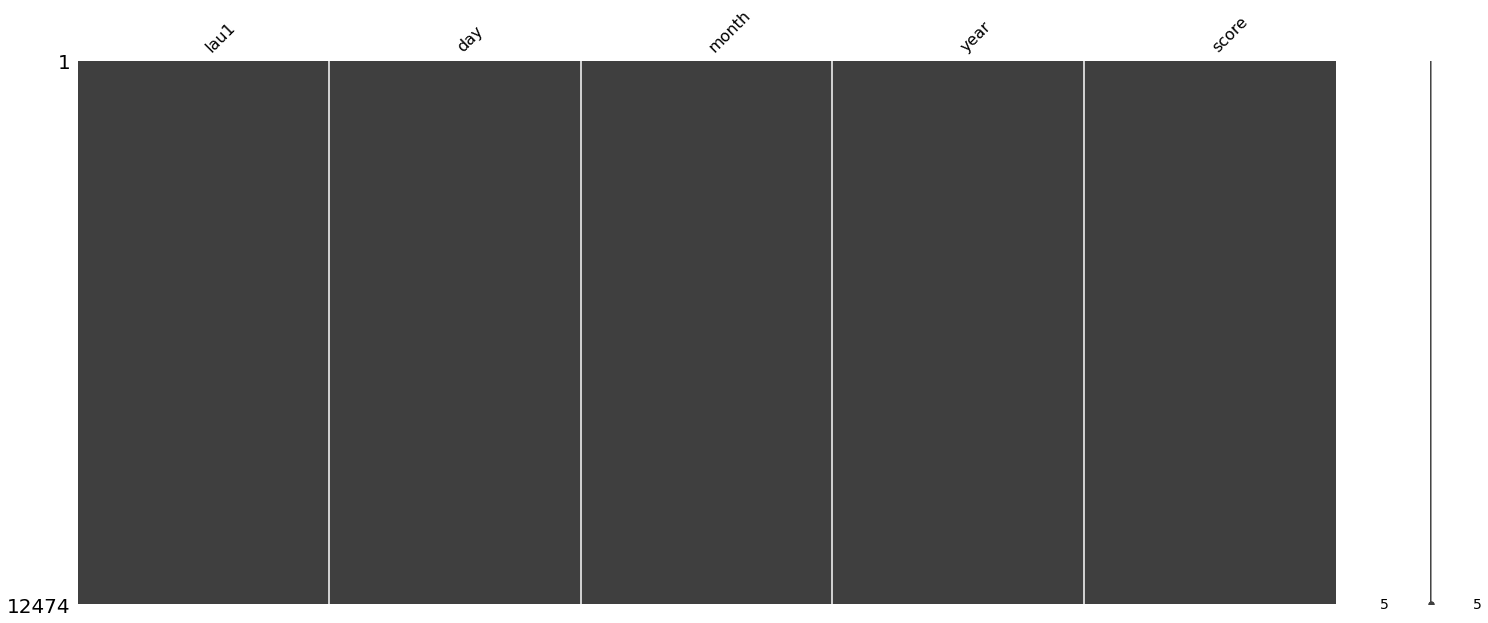

In [24]:
missingno.matrix(concated)

In [25]:
days = np.sort(concated.day.unique())
days

array([ 1, 16], dtype=int64)

In [26]:
months = np.sort(concated.month.unique())
months

array([ 5,  6,  7,  8,  9, 10, 11], dtype=int64)

In [27]:
years = np.sort(concated.year.unique())
years

array([2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020,
       2021, 2022, 2023], dtype=int64)

In [28]:
df = concated[(concated['month'] >= 5) & (concated['month'] <= 8)].copy()

In [29]:
condition = df[(df['month'] == 8) & (df['day'] == 16)].index
df.drop(condition, inplace = True)
df

,lau1,day,month,year,score
0,πορου,1,8,2019,9.999924e-01
1,πορου,16,7,2019,9.999822e-01
4,πορου,1,7,2019,9.999705e-01
9,πορου,16,6,2019,9.997587e-01
10,πορου,1,8,2015,9.993917e-01
...,...,...,...,...,...
12469,γαλατσιου,16,5,2023,1.994010e-04
12470,υδρας,16,5,2023,1.133127e-05
12471,αγκιστριου,16,5,2023,6.812093e-06
12472,σπετσων,16,5,2023,2.022864e-06


In [30]:
bins_path = f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Bins_2023.csv'

bins = []

with open(bins_path, mode='r', newline='') as file:
    reader = csv.reader(file)
    for row in reader:
        bins.extend(map(float, row))

print(bins)

[0.0, 0.0109535019552355, 0.1258617634854501, 0.371464711473195, 0.6083890460605226, 0.775752340553361, 0.8789927204097515, 0.9379458270294232, 0.9772513638095512, 0.9934679359431164, 1.0]


In [31]:
df['risk_class'] = pd.cut(df['score'], bins=bins, labels=False, include_lowest=True)
df.head(10)

,lau1,day,month,year,score,risk_class
0,πορου,1,8,2019,0.999992,9
1,πορου,16,7,2019,0.999982,9
4,πορου,1,7,2019,0.999970,9
9,πορου,16,6,2019,0.999759,9
10,πορου,1,8,2015,0.999392,9
11,πορου,1,6,2019,0.999076,9
13,πορου,1,8,2017,0.998521,9
14,πορου,1,8,2011,0.998505,9
15,πορου,1,8,2014,0.997952,9
16,πορου,1,8,2012,0.996563,9


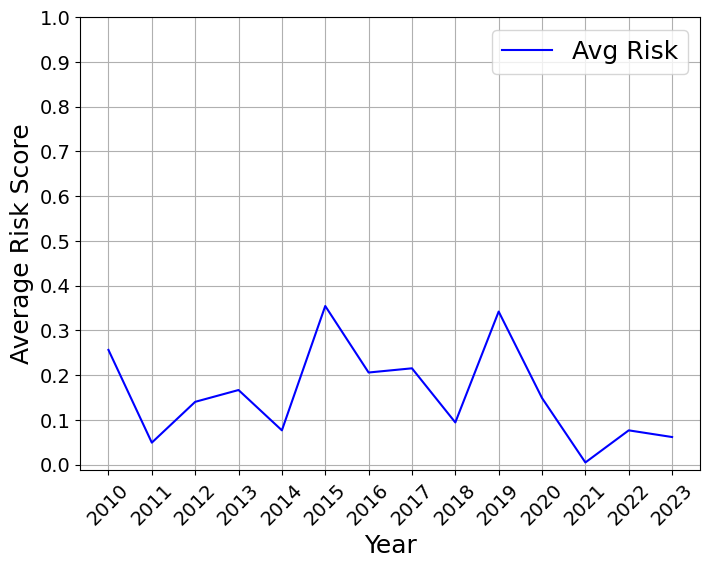

In [32]:
plot_trend_curve(df, plot_max = False, score_col = 'score', plot_cases=False, y_label='Average Risk Score')

In [33]:
risk_2022_over_7 = df[(df['year'] == 2022) & (df['risk_class'] >= 7)].copy()
risk_2022_over_7.reset_index(drop = True, inplace = True)
risk_2022_over_7

,lau1,day,month,year,score,risk_class
0,πορου,1,8,2022,0.993052,8
1,πορου,16,7,2022,0.989905,8
2,πορου,1,7,2022,0.980111,8


In [34]:
risk_2023_over_7 = df[(df['year'] == 2023) & (df['risk_class'] >= 7)].copy()
risk_2023_over_7.reset_index(drop = True, inplace = True)
risk_2023_over_7

,lau1,day,month,year,score,risk_class
